---

$$\boxed{\color{pink}{\text{Agentic AI Workshop Day-2}}}$$

$${\color{yellow}{\underline{\text{Theme}}}: \text{retrieval augmented generation (RAG)}}$$

$${\color{yellow}{\underline{\text{Goal}}}: \text{scale retrieval using RAG}}$$


**Topics**:

1. Understand why embeddings alone are not enough

2. Build a retrieval pipeline using FAISS

3. Connect retrieval → generation (RAG)

4. Run local multilingual LLM inference

5. Generate crime summaries

6. Evaluate when RAG helps and when it fails

---


---

Import libraries

---

In [1]:
import pandas as pd
import numpy as np
import math
import random
import os
import sys
import re
from tqdm import tqdm
import unicodedata
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('dark_background')
%matplotlib inline

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.9.1+cpu
CUDA available: False


---

Mount Google Drive if running in Colab

---

In [2]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/MSIS Coursework/OddSem2025MAHE/Share/Agentic Workshop/NoStudentAccess'
    DATA_DIR = DIR + '/Data/'
    !pip install faiss-cpu --quiet
    os.chdir(DIR)
else:
    DATA_DIR = '../Data/'

---

Load Udupi crime data

Expected CSV columns:

- Crime Type
- Location
- Day of Week (label encoded: 0–6)
- Time of Day (0–3)
- Day
- Month
- Year
- Crime Description (Kannada text)

---

In [3]:
## Load Udupi crime data
file = DATA_DIR+'UdupiCrimeData.csv'
df= pd.read_csv(file, header = 0).dropna()
df.reset_index(inplace = True)

print('Udupi crime dataset')
print('-----------')
print('Number of records = %d'%(df.shape[0]))
print('Number of features = %d\n'%(df.shape[1]))
df.head(5)

Udupi crime dataset
-----------
Number of records = 13457
Number of features = 9



,index,Crime Type,Location,Day of Week,Time of Day,Day,Month,Year,Crime Description
0,0,ಮಟ್ಕಾ ಜುಗಾರಿ ಪ್ರಕರಣ,ಗಂಗೊಳ್ಳಿ,6.0,2.0,29.0,2.0,2020.0,ಭೀಮಶಂಕರ್ ಎಸ್ ಎಸ್ ಪಿ ಎಸ್ ಐ ಗಂಗೊಳ್ಳಿ ಪೊಲಿಸ್ ಠಾಣೆ...
1,1,ಅಸ್ವಾಭಾವಿಕ ಮರಣ ಪ್ರಕರಣ,ಕೊಲ್ಲೂರು,6.0,0.0,29.0,2.0,2020.0,ಪಿರ್ಯಾದಿದಾರರಾಧ ಶ್ರೀಮತಿ ಸಂಧ್ಯಾ ( 59 ವರ್ಷ) ಗಂಡ: ...
2,2,ಅಸ್ವಾಭಾವಿಕ ಮರಣ ಪ್ರಕರಣ,ಉಡುಪಿ,6.0,1.0,29.0,2.0,2020.0,"ಪಿರ್ಯಾದಿದಾರರಾದ ಕೆ ರಾಘವೇಂದ್ರ ಸರಳಾಯ(67), ತಂದೆ: ದ..."
3,3,ಮನುಷ್ಯ ಕಾಣೆ ಪ್ರಕರಣ,ಶಿರ್ವಾ,4.0,0.0,27.0,2.0,2020.0,"ಪಿರ್ಯಾದಿದಾರರಾದ ಕಿಶೋರ್‌ಆಚಾರ್ಯ (31), ತಂದೆ:ಉಪೇಂದ್..."
4,8,ಅಪಘಾತ ಪ್ರಕರಣ,ಮಲ್ಪೆ,5.0,1.0,21.0,2.0,2020.0,ದಿನಾಂಕ 21/02/2020 ರಂದು 14:00 ಗಂಟೆಗೆ ಪಿರ್ಯಾದಿದಾ...


---

User-defined functions for normalizing Kannada text and tokenizing the resulting normalized text


---

In [14]:
def normalize_text(text):
  text = str(text)
  # Remove every character that is NOT a Kannada character OR whitespace leaving only Kannada letters,
  # vowels, and matras, and spaces and line breaks.
  # Unicode range for Kannada: U+0C80 – U+0CFF, Devanagari: U+0900 – U+097F, Tamil: U+0B80 – U+0BFF
  text = re.sub(r"[^\u0C80-\u0CFF\s]", "", text)
  # Replace one or more whitespace characters with a single space
  text = re.sub(r"\s+", " ", text)
  return text.strip()

def tokenize(text):
  return normalize_text(text).split()

---

Load pretrained embedding model and embed crime reports

---

In [17]:
texts = df["Crime Description"].apply(normalize_text).tolist()

In [ ]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

texts = df["Crime Description"].apply(normalize_text).tolist()

# Embed crime reports into an embedding matrix

X_embeddings = embedder.encode(texts,
                               batch_size = 32,
                               show_progress_bar = True,
                               convert_to_numpy = True)

RuntimeError: Failed to import transformers.trainer because of the following error (look up to see its traceback):
This is not allowed since there's already a kernel registered from python overriding int8_mm_dequant's behavior for CompositeExplicitAutograd dispatch key and bitsandbytes namespace.

---

**FAISS Index (Scalable Retrieval)**:

- Fast Approximate Nearest Neighbor Search
  
- Optimized for large vector collections
  
- Used in real-world RAG systems
  
---

In [6]:
import faiss

In [18]:
## Build FAISS index for embeddings built using
## the pretrained model
dim = X_embeddings.shape[1]

index = faiss.IndexFlatL2(dim)
index.add(X_embeddings)

index.ntotal

NameError: name 'X_embeddings' is not defined

In [8]:
## User-defined function for retrieving top-5
## similar embeddings
def retrieve(query, k = 5):
    query = normalize_text(query)
    q_emb = embedder.encode([query], convert_to_numpy = True)
    distances, indices = index.search(q_emb, k)
    return df.iloc[indices[0]]['Crime Description']

In [9]:
## Test retrieval and inspect the top result
query = "ಮೊಬೈಲ್ ಫೋನ್ ಕಳವು"
results = retrieve(query)
print(results)
print(f'Top result {results.index[0]}:\n {results[results.index[0]]}')

NameError: name 'embedder' is not defined

---

Custom embedder module inherited from nn.Module

---

In [10]:
## Simple embedder module
class SimpleEmbedder(nn.Module):
    def __init__(self, vocab_size, dim = 8):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, dim)

    def forward(self, x):
        return self.embed(x).mean(dim = 0)

In [34]:
class SimpleEmbedderV4(nn.Module):
    def __init__(self, vocab_size, dim=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, dim)
        # learns a single importance score per word
        self.attention = nn.Linear(dim, 1)
        self.network = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, dim)
        )

    def forward(self, x):
        embedded = self.embed(x)              # (n_tokens, 64)
        
        # compute importance score for each token
        scores = self.attention(embedded)     # (n_tokens, 1)
        weights = torch.softmax(scores, dim=0)# (n_tokens, 1) sums to 1
        
        # weighted average instead of plain mean
        pooled = (weights * embedded).sum(dim=0)  # (64,)
        
        return self.network(pooled)           # (64,)

In [35]:
## Build a dictionary of crime groups with the
## keys as the crime types and the values as a list
## of crime descriptions corresponding to that type
crime_groups = defaultdict(list)

# Voicabulary dictionary
vocab_counter = Counter()

for index, row in df.iterrows():
    tokens = tokenize(texts[index])
    vocab_counter.update(tokens)
    crime_groups[row['Crime Type']].append(tokens)

In [36]:
# Build dictionaries for training the custom embedding model
word2idx = {w:i for i, w in enumerate(vocab_counter.keys())}
idx2word = {i:w for w, i in word2idx.items()}

In [37]:
## User-defined function to encode the crime reports
def encode_doc(tokens):
    return [word2idx[t] for t in tokens if t in word2idx]

In [38]:
## Custom embedding model based on the crime type
# Model
embed_dim = 64
# model = SimpleEmbedder(len(word2idx), dim = embed_dim)
model = SimpleEmbedderV4(len(word2idx), dim = embed_dim)
# Optimizer
optimizer = optim.Adam(model.parameters(), lr = 1e-03)
# Loss function
loss_fn = nn.CosineEmbeddingLoss()

In [39]:
num_epochs = 500
epoch_loss = []

for epoch in range(num_epochs):
    total_loss = 0.0

    for crime_type, docs in crime_groups.items():
        if len(docs) < 2:
            continue

        # sample 3 pairs instead of 1
        for _ in range(3):                    # ← loop now wraps everything
            
            # positive pair
            d1_tokens, d2_tokens = random.sample(docs, 2)
            
            # negative pair
            neg_crime = random.choice([
                ct for ct in crime_groups.keys()
                if ct != crime_type
            ])
            d3_tokens = random.choice(crime_groups[neg_crime])

            # Encode
            d1 = torch.tensor(encode_doc(d1_tokens))
            d2 = torch.tensor(encode_doc(d2_tokens))
            d3 = torch.tensor(encode_doc(d3_tokens))

            # skip if any document encoded to empty
            # (all tokens were OOV)
            if len(d1) == 0 or len(d2) == 0 or len(d3) == 0:
                continue

            # Forward pass
            e1 = model(d1)
            e2 = model(d2)
            e3 = model(d3)

            # Losses
            pos_label = torch.tensor(1.0)
            neg_label = torch.tensor(-1.0)
            loss_pos = loss_fn(e1, e2, pos_label)
            loss_neg = loss_fn(e1, e3, neg_label)
            loss = loss_pos + loss_neg

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

    epoch_loss.append(total_loss)
    print(f'Epoch {epoch} loss: {total_loss:.4f}')

Epoch 0 loss: 264.8575
Epoch 1 loss: 217.9466
Epoch 2 loss: 191.8037
Epoch 3 loss: 158.4491
Epoch 4 loss: 148.6030
Epoch 5 loss: 129.5580
Epoch 6 loss: 126.1974
Epoch 7 loss: 117.3161
Epoch 8 loss: 105.7744
Epoch 9 loss: 105.4220


KeyboardInterrupt: 

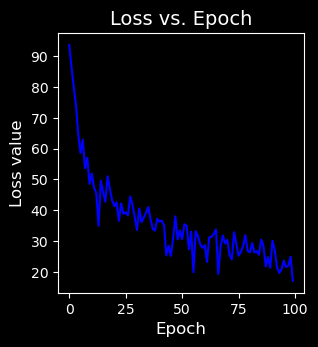

In [24]:
## Plot loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(epoch_loss, 'b')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.set_title('Loss vs. Epoch', fontsize = 14);

In [25]:
## Generate custom embeddings for the crime reports

# Create empty embeddings matrix
X_customembeddings = np.empty((df.shape[0], embed_dim))

# Populate the embeddings matrix with the custom embeddings
for i in range(df.shape[0]):
  X_customembeddings[i] = model.forward(torch.tensor(encode_doc(texts[i]))).detach().numpy()


In [26]:
# Build FAISS index for embeddings built using
## the custom embedding model
dim = X_customembeddings.shape[1]

index = faiss.IndexFlatL2(dim)
index.add(X_customembeddings)

index.ntotal

13457

In [27]:
## User-defined function for retrieving top-5
## similar embeddings
def semantic_search(query, k = 5):
  query = normalize_text(query)
  q_emb = model.forward(torch.tensor(encode_doc(query))).detach().numpy().reshape(1, -1)
  distances, indices = index.search(q_emb, k)
  return df.iloc[indices[0]]['Crime Description']


In [33]:
## Test retrieval and inspect the top result
query = """
ಮೊಬೈಲ್ ಕಳ್ಳತನ
ಮೊಬೈಲ್ ಫೋನ್ ಕಳವು
ಮೊಬೈಲ್ ಕಿತ್ತುಕೊಂಡರು
ಮೊಬೈಲ್ ತೆಗೆದುಕೊಂಡು ಹೋದರು
ಮೊಬೈಲ್ ನಾಪತ್ತೆ
"""
results = semantic_search(query)
print(results)
print(f'Top result {results.index[0]}:\n {results[results.index[0]]}')

13399    ದಿನಾಂಕ 10/08/2015ರಂದು ಪಿರ್ಯಾದಿ ಎಸ್‌. ನಾರಯಣ ನಾಯ...
9684     ದಿನಾಂಕ:2೦/11/2016 ರಂದು ಬೆಳಿಗ್ಗೆ ಸುಮಾರು 02:00 ಗ...
8594     ದಿನಾಂಕ 08/04/2016 ರಂದು 17:15 ಗಂಟೆಗೆ ಶೇಖರ ಪೋಲಿಸ...
11438    ದಿನಾಂಕ 08/04/2016 ರಂದು 10:30 ಗಂಟೆಯಿಂದ ದಿನಾಂಕ 0...
1527     ದಿನಾಂಕ 11/09/2019 ರಂದು ಪಿರ್ಯಾದಿದಾರರಾದ ಕಿಶೋರ ಕು...
Name: Crime Description, dtype: object
Top result 13399:
 ದಿನಾಂಕ 10/08/2015ರಂದು ಪಿರ್ಯಾದಿ ಎಸ್‌. ನಾರಯಣ ನಾಯಕ್‌, ತಂದೆ: ಹರಿಯಪ್ಪ ನಾಯಕ್‌, ವಾಸ: ಮೂಡುಸಗ್ರಿ, ಕುಂಜಿಬೆಟ್ಟು ಅಂಚೆ, ಶಿವಳ್ಳೀ ಗ್ರಾಮ, ಉಡುಪಿರವರು ಆಟೋರಿಕ್ಷಾ ನಂಬ್ರ ಕೆಎ 20 ಬಿ 6974 ನೇದರಲ್ಲಿ ಇಬ್ಬರು ಪ್ರಯಾಣಿಕರನ್ನು ಕುಳ್ಳಿರಿಸಿಕೊಂಡು ಡಿ.ಸಿ ಅಫೀಸ್ ರಸ್ತೆಯಿಂದ ಪೊಲೀಸ್ ಠಾಣಾ ಬಳಿ ರಸ್ತೆಗೆ 10:30 ಗಂಟೆಗೆ ತಲುಪುವಾಗ ಹಿಂದಿನಿಂದ ಕೆಎ 19 ಎಮ್‌ಸಿ 4293 ನೇದರ ಕಾರು ಚಾಲಕನು ಹಿಂದಿನಿಂದ ತಾನು ಚಲಾಯಿಸಿಕೊಂಡು ಬಂದ ಕಾರನ್ನು ಅತೀ ವೇಗ ಮತ್ತು ಅಜಾಗರೂಕತೆಯಿಂದ ಚಲಾಯಿಸಿಕೊಂಡು ಬಂದು ಎಸ್‌. ನಾರಯಣ ನಾಯಕ್‌ರವರ ಆಟೋರಿಕ್ಷಾಕ್ಕೆ ಢಿಕ್ಕಿ ಹೊಡೆದು ನಂತರ ಪಕ್ಕದ ವಿದ್ಯುತ್ ಕಂಬಕ್ಕೆ ಢಿಕ್ಕಿ ಹೊಡೆದನು. ಪರಿಣಾಮ ಆಟೋರಿಕ್ಷಾದಲ್ಲಿದ್ದ ಇಬ್ಬರು ಪ್ರಯಾಣಿಕರಿಗೆ ಗಾಯವಾಗಿದ್ದು, ಪಿರ್ಯಾದಿದಾರರಿಗೆ ಹಣೆಗೆ ತರಚಿದ ಗಾಯವಾಗಿರುತ್ತದೆ ಈ ಬಗ್ಗೆ ಮಣಿಪಾಲ ಠಾಣೆ ಅಪರಾಧ ಕ್ರಮಾಂಕ 161/15 ಕಲ

---

We move from retrieval to retrieval augmented generation (RAG) using the open source 4-bit quantized Qwen2 LLM $$\color{yellow}{\text{qwen2-1\_5b-instruct-q4\_0.gguf}}$$ available at  https://huggingface.co/Qwen/Qwen2-1.5B-Instruct-GGUF

---

In [30]:
from llama_cpp import Llama

# qwen2-1_5b-instruct-q4_0
llm = Llama(
    model_path = "../Models/qwen2-1_5b-instruct-q4_0.gguf",
    n_ctx = 5096,
    n_threads = 8
    )

ModuleNotFoundError: No module named 'llama_cpp'

---

User-defined function to construct RAG prompt using the query from the user appended as the "query" and the top related crime descriptions appended as the context.

---


In [ ]:
def rag_generate(query, context):
  prompt = f"""
<|im_start|>system
ನೀವು ಕರ್ನಾಟಕ ಪೊಲೀಸ್ ಇಲಾಖೆಗೆ ಸಹಾಯ ಮಾಡುವ AI ಸಹಾಯಕ.
ನೀವು ಕೇವಲ FIR ಮಾಹಿತಿಯ ಆಧಾರದ ಮೇಲೆ ಉತ್ತರಿಸುತ್ತೀರಿ.
<|im_end|>

<|im_start|>user
ಕೆಳಗಿನ FIR ವಿವರಗಳನ್ನು ಗಮನಿಸಿ.

ನಿಯಮಗಳು:
- FIR ವಿವರಗಳಲ್ಲಿ ಇಲ್ಲದ ಮಾಹಿತಿಯನ್ನು ಸೇರಿಸಬಾರದು
- ಇಂಗ್ಲಿಷ್ ಬಳಸಬಾರದು
- ಉತ್ತರ ಕನ್ನಡದಲ್ಲಿರಬೇಕು

FIR ವಿವರಗಳು:
{context}

ಪ್ರಶ್ನೆ:
{query}
<|im_end|>

<|im_start|>assistant
"""



  output = llm(
    prompt,
    max_tokens = 300,
    temperature = 0.15,
    top_p = 0.9,
    repeat_penalty = 1.1,
    stop = ["<|im_end|>"]
)

  return output["choices"][0]["text"]


---

User-defined function to prepare the query and the context for the RAG

---

In [ ]:
def ask_fir_assistant(query, k = 2):
    retrieved = semantic_search(query, k)
    context = "\n\n".join(retrieved)
    return rag_generate(query, context)

In [ ]:
query = "ಮೊಬೈಲ್ ಫೋನ್ ಕಳವು"
ask_fir_assistant(query)

llama_perf_context_print:        load time =   62407.56 ms
llama_perf_context_print: prompt eval time =   62405.53 ms /  3103 tokens (   20.11 ms per token,    49.72 tokens per second)
llama_perf_context_print:        eval time =   27028.70 ms /   299 runs   (   90.40 ms per token,    11.06 tokens per second)
llama_perf_context_print:       total time =   90637.18 ms /  3402 tokens
llama_perf_context_print:    graphs reused =        288


'FIR (Fire Investigation Report) is a document that records the investigation of an incident involving fire. It includes details about the fire, such as when it occurred, where it happened, and who was involved. The report also includes information about the cause of the fire, which could be due to negligence or arson.\n\nThe FIR in your provided text seems to be related to a fire that occurred on June 30th, 2016 at around 5:00 PM. It states that there were two people involved - a man named Kukuya (46) and a woman named Kukuya (46). The report also mentions that the fire started in the kitchen of a house located on the street called "Kukuya Street" near the town of Kukuya, which is in the district of Kukuya in the state of Karnataka. \n\nThe report further states that the man was injured and had to be taken to the hospital, but he did not survive. The woman was also injured but she survived. It mentions that the fire started due to negligence on the part of the man.\n\nThe FIR also inc